In [1]:
# import galstreams
# mws = galstreams.MWStreams(verbose=False)

import sys, pickle, os
from importlib import reload
from tqdm import tqdm, trange

import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm

import agama 
Gyr_to_AgamaTime = 1.0227 # 1 Gyr in Agama time units (kpc/(km/s))
import nbody_streams.agama_helper as ah

import emcee
import corner

from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
from astropy import table

In [2]:
sys.path.append('../scripts/')
from coordinate_utils import get_rotation_matrix, sf_to_icrs, icrs_to_sf
from generate_sim_stream import create_stream_particle_spray
from stream_likelihood import log_likelihood, make_spline, log_prior, log_probability
from stream_data_utils import read_in_data

In [3]:
aau_member_path = '../data/aau_members.csv'
aau_distance_path = '../data/aau_bhb_rrl.csv'

aau_table = pd.read_csv(aau_member_path)
aau_bhb_rrl_data = pd.read_csv(aau_distance_path)

aau_bhb_rrl_data.columns = aau_bhb_rrl_data.columns.str.lower()

df_aau, prog_pars_aau, prog_pars_icrs_aau, df_distance_aau = read_in_data(aau_table, 'distance_modulus', aau_bhb_rrl_data)

prog_pars_aau[2] = 10**(((prog_pars_aau[2]) + 5) / 5) / 1000.0
prog_pars_icrs_aau[2] = 10**(((prog_pars_icrs_aau[2]) + 5) / 5) / 1000.0 

jet_member_path = '../data/jet_members.csv'

jet_table = pd.read_csv(jet_member_path)

df_jet, distance_fit_jet, prog_pars_jet, prog_pars_icrs_jet = read_in_data(jet_table, 'bhb_dist')

In [4]:
#linear_fit = lambda t: -0.0356 * t + 1.0339

In [5]:
#Constructing a data dictionary given stream data_frame
data_dict_aau = dict(
    phi1_obs = df_aau['phi1'].values,
    phi1_obs_dist = df_distance_aau['phi1'].values,
    phi2_obs = df_aau['phi2'].values,
    rv_obs = df_aau['vel_calib'].values,
    rv_obs_errors = df_aau['vel_calib_std'].values,
    dist_obs = 10**(((df_distance_aau['distance_modulus'].values) + 5) / 5) / 1000.0,
    dist_obs_errors = ((10**(((df_distance_aau['distance_modulus'].values) + 5) / 5) / 1000.0)*0.1),
    pmra_cosdec_obs = df_aau['pmra'].values,
    pmra_cosdec_obs_errors = df_aau['pmra_error'].values,
    pmdec_obs = df_aau['pmdec'].values,
    pmdec_obs_errors = df_aau['pmdec_error'].values,
)

data_dict_jet = dict(
    phi1_obs = df_jet['phi1'].values,
    phi2_obs = df_jet['phi2'].values,
    rv_obs = df_jet['vel_calib'].values,
    rv_obs_errors = df_jet['vel_calib_std'].values,
    dist_obs = df_jet['bhb_dist'].values,
    dist_obs_errors = (df_jet['bhb_dist'].values*0.1),
    pmra_cosdec_obs = df_jet['pmra'].values,
    pmra_cosdec_obs_errors = df_jet['pmra_error'].values,
    pmdec_obs = df_jet['pmdec'].values,
    pmdec_obs_errors = df_jet['pmdec_error'].values,
)

In [6]:
BASE_POT_PATH = '../potential_files/'
potMW_path = os.path.join(BASE_POT_PATH, 'base_mw_pot.ini')
## potential models to load
basePot = agama.Potential(file=potMW_path)
scaleNFW_half = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.5, 1],[0, 1, 1]])
potHalf= basePot + scaleNFW_half
NFW = agama.Potential(type= 'NFW', mass = 5.5427e11, scaleRadius = 15.626)
potStat = basePot + NFW
#pot_spheroid.density([10, 0, 0], t=0), pot_spheroid.density([10, 0, 0], t=-5)
#pot_spheroid = agama.Potential(type='spheroid', mass=1e12, scaleradius=20, scale=[[-5, 0.5, 1],[0, 1, 1]])

In [7]:
print(potHalf)
print(potStat)

CompositePotential{ MiyamotoNagai, MiyamotoNagai, MiyamotoNagai, Dehnen, Dehnen, Scaled NFW } (symmetry: Axisymmetric)
CompositePotential{ MiyamotoNagai, MiyamotoNagai, MiyamotoNagai, Dehnen, Dehnen, NFW } (symmetry: Axisymmetric)


In [8]:
#Constructing stream progenitor present-day coordinates and information

prog_mass, prog_scaleradius =  20_000, 10/1_000 # Msun, kpc

num_particles = 3_000

Age_stream_inGyr = 5.0

R = np.array([[-0.69533693,  0.61240175, -0.37612584],
                    [-0.62909984, -0.26561497,  0.73053548],
                 [ 0.34747655,  0.744589,    0.56995374]])

jet_rot_matrix = u.Quantity(R, unit=u.dimensionless_unscaled)

#jet_rot_matrix = get_rotation_matrix('Jet-F22', mws = mws)
#print(jet_rot_matrix)

static_pot_bestfit_6D = [0, 0.15, 30.08, -0.64, -1.46, 272.41]

icrs_coord_ra, icrs_coord_dec = sf_to_icrs(static_pot_bestfit_6D[0], static_pot_bestfit_6D[1], jet_rot_matrix)
print(icrs_coord_ra, type(icrs_coord_ra))
print(icrs_coord_dec, type(icrs_coord_dec))

dist, pmra, pmdec, rv = static_pot_bestfit_6D[-4:]

jet_c = coord.SkyCoord(
        ra=icrs_coord_ra*u.degree, dec=icrs_coord_dec*u.degree, distance=dist*u.kpc, 
        pm_ra_cosdec=pmra*u.mas/u.yr,
        pm_dec=pmdec*u.mas/u.yr,
        radial_velocity=rv*u.km/u.s
    )
    
rep = jet_c.transform_to(coord.Galactocentric) # units here are kpc, km/s
    
prog_wtoday_gal = np.array(
        [rep.x.value, rep.y.value, rep.z.value,
         rep.v_x.value, rep.v_y.value, rep.v_z.value])

print(prog_wtoday_gal)

138.50121429303636 <class 'numpy.ndarray'>
-22.00159581100559 <class 'numpy.ndarray'>
[ -17.64031256  -26.95909359    9.37039313   -1.49156767  -91.40702591
 -102.2028583 ]


In [9]:
stream_model_half = create_stream_particle_spray(
    pot_host=potHalf, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_wtoday_gal, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=300,
    #add_perturber={'mass':0},
)
stream_model_stat = create_stream_particle_spray(
    pot_host=potStat, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_wtoday_gal, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=300,
    #add_perturber={'mass':0},
)

In [10]:
# sps_movie_dir = 'jet_disrupting_gif'
# os.makedirs(sps_movie_dir, exist_ok= True)

# n_particles, n_timesteps, __ = stream_model_stat['part_xv'].shape

# for t in range(n_timesteps):
    
#     inc = (t*Age_stream_inGyr)/n_timesteps
#     age = inc-Age_stream_inGyr

#     fig = plt.figure(figsize=(8,8))
#     ax = fig.add_subplot(111, projection='3d')
    
#     ax.scatter3D(
#             stream_model_stat['part_xv'][:, t, 0],
#             stream_model_stat['part_xv'][:, t, 1],
#             stream_model_stat['part_xv'][:,t, 2],
#             s=2, c='tab:blue', alpha=0.6,label='Jet stream'
#         )
#     ax.scatter3D(
#             stream_model_stat['prog_xv'][t, 0],
#             stream_model_stat['prog_xv'][t, 1],
#             stream_model_stat['prog_xv'][t, 2],
#             s=30, c='tab:red', zorder=5, label = 'Progenitor (not to scale)'
#         )
#     # static progenitor trail
#     ax.plot3D(
#         stream_model_stat['prog_xv'][:t+1, 0],
#         stream_model_stat['prog_xv'][:t+1, 1],
#         stream_model_stat['prog_xv'][:t+1, 2],
#         c='tab:red', linestyle='--', linewidth=0.5, alpha=0.5
#     )
    
#     legend = ax.legend(loc='upper left', fontsize=10, frameon=False)

#     #view
#     elev = 30
#     azim = 300
    
#     fname = f'{sps_movie_dir}/step_{t:04d}.png'
#     plt.savefig(fname, dpi=80)
#     plt.close()

In [11]:
# #Making a movie
# n_particles_h, n_timesteps_h, __h = stream_model_half['part_xv'].shape

# n_particles_s, n_timesteps_s, __s = stream_model_stat['part_xv'].shape

# frames_dir = 'jet_half_mass_evolve_gif'
# os.makedirs(frames_dir, exist_ok=True)

# for t in range(n_timesteps_h):
#     #print(stream_model_half['part_xv'][:, 0, 0])  # x at first timestep
#     inc = (t*Age_stream_inGyr)/n_timesteps_h
#     age = inc-Age_stream_inGyr
#     #print(f"{age:.2f}")
    
#     fig = plt.figure(figsize=(8,8))
#     ax = fig.add_subplot(111, projection='3d')
#     ax.set_facecolor('black')
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.pane.set_edgecolor('none')
#     ax.yaxis.pane.set_edgecolor('none')
#     ax.zaxis.pane.set_edgecolor('none')
#     ax.grid(False)
#     ax.set_axis_off()

    
#     # plot all particles at this timestep
#     ax.scatter3D(
#         stream_model_half['part_xv'][:, t, 0],
#         stream_model_half['part_xv'][:, t, 1],
#         stream_model_half['part_xv'][:, t, 2],
#         s=2, c='tab:pink', alpha=0.6,label='Evolving'
#     )
#     ax.scatter3D(
#         stream_model_stat['part_xv'][:, t, 0],
#         stream_model_stat['part_xv'][:, t, 1],
#         stream_model_stat['part_xv'][:, t, 2],
#         s=2, c='#703BE7', alpha=0.6,label='Static'
#     )

#     # ax.scatter3D(
#     # prog_wtoday_gal[0], prog_wtoday_gal[1], prog_wtoday_gal[2],
#     # s=20, c='white', zorder=5
#     # )

#     # half-mass progenitor trail + dot
    
#     # half-mass progenitor trail
#     ax.plot3D(
#         stream_model_half['prog_xv'][:t+1, 0],
#         stream_model_half['prog_xv'][:t+1, 1],
#         stream_model_half['prog_xv'][:t+1, 2],
#         c='tab:pink', linestyle='--', linewidth=0.5, alpha=0.5
#     )
    
#     # static progenitor trail
#     ax.plot3D(
#         stream_model_stat['prog_xv'][:t+1, 0],
#         stream_model_stat['prog_xv'][:t+1, 1],
#         stream_model_stat['prog_xv'][:t+1, 2],
#         c='#703BE7', linestyle='--', linewidth=0.5, alpha=0.5
#     )
    
#     # two white dots, only label one to avoid duplicate legend entry
#     ax.scatter3D(
#         stream_model_half['prog_xv'][t, 0],
#         stream_model_half['prog_xv'][t, 1],
#         stream_model_half['prog_xv'][t, 2],
#         s=20, c='white', zorder=5, label='Progenitor'
#     )
#     ax.scatter3D(
#         stream_model_stat['prog_xv'][t, 0],
#         stream_model_stat['prog_xv'][t, 1],
#         stream_model_stat['prog_xv'][t, 2],
#         s=20, c='white', zorder=5
#     )

#     legend = ax.legend(loc='upper left', fontsize=10, frameon=False)
#     for text in legend.get_texts():
#         text.set_color('white')

#     # white time label
#     ax.text2D(0.05, 0.05, f't = {age:.2f} Gyr', color='white', fontsize=12, transform=ax.transAxes)
    
#     # rotate angle with each frame
#     elev = 20 + 10 * np.sin(2 * np.pi * t / n_timesteps_h)
#     azim = (t / n_timesteps_h) * 360
#     ax.view_init(elev=elev, azim=azim)
    
#     fname = f'{frames_dir}/step_{t:04d}.png'
#     plt.savefig(fname, dpi=80)
#     plt.close()

In [12]:
print(stream_model_half['part_xv'][:, -1, :3].mean(axis=0))
print(stream_model_stat['part_xv'][:, -1, :3].mean(axis=0))

[-17.4616863  -26.66806812   9.27831435]
[-17.42813691 -26.60924315   9.26662493]


In [13]:
#plotting the present day position of hte progenitors

(0.0, -5.0)

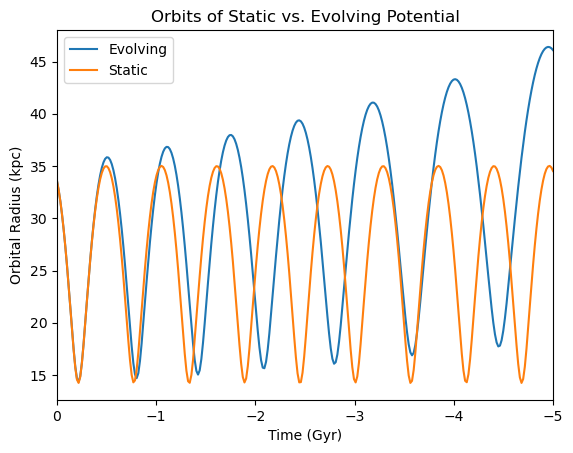

In [15]:
stream_model_half['times']
plt.title('Orbits of Static vs. Evolving Potential')
plt.plot(stream_model_half['times'], np.linalg.norm(stream_model_half['prog_xv'][:, :3], axis=1), label= 'Evolving')
plt.plot(stream_model_stat['times'], np.linalg.norm(stream_model_stat['prog_xv'][:, :3], axis=1), label = 'Static')
plt.legend()
plt.ylabel('Orbital Radius (kpc)')
plt.xlabel('Time (Gyr)')
plt.xlim(0,-5)

(0.0, -5.0)

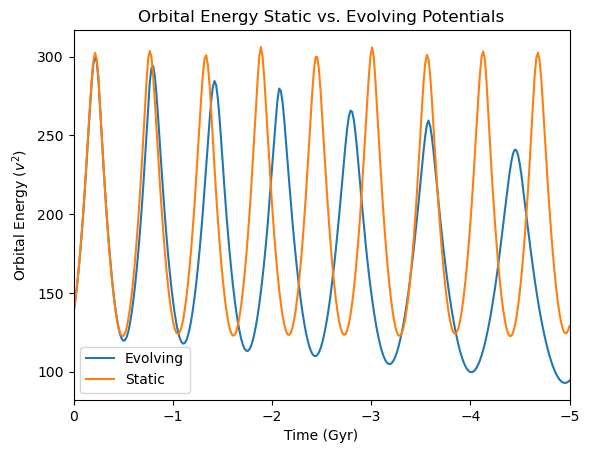

In [16]:
plt.title('Orbital Energy Static vs. Evolving Potentials')
plt.plot(stream_model_half['times'], np.linalg.norm(stream_model_half['prog_xv'][:, 3:], axis=1), label= 'Evolving')
plt.plot(stream_model_stat['times'], np.linalg.norm(stream_model_stat['prog_xv'][:, 3:], axis=1), label = 'Static')
plt.legend()
plt.ylabel('Orbital Energy ($v^2$)')
plt.xlabel('Time (Gyr)')
plt.xlim(0,-5)

In [94]:
#plotting the phase angle of both orbits

In [95]:
np.degrees(np.arctan(np.linalg.norm(stream_model_stat['prog_xv'][:, 3:], axis=1)))

array([89.55568169, 89.54432488, 89.53906191, 89.54056357, 89.54865578,
       89.56248795, 89.58076866, 89.60206707, 89.62506055, 89.64867242,
       89.67210656, 89.69481573, 89.71643873, 89.73672827, 89.75547572,
       89.77242879, 89.7871931 , 89.79912329, 89.80727586, 89.81061053,
       89.80851108, 89.80116392, 89.78812943, 89.7719483 , 89.7538774 ,
       89.73420472, 89.71310182, 89.69072573, 89.6672963 , 89.64316813,
       89.61890246, 89.59533046, 89.57358297, 89.55504808, 89.54121622,
       89.53340894, 89.5324581 , 89.53846854, 89.55078618, 89.56818948,
       89.58920243, 89.61238878, 89.63654007, 89.66074489, 89.68437394,
       89.70702245, 89.72843898, 89.74845324, 89.76690147, 89.78353717,
       89.79790135, 89.80768584, 89.81108989, 89.80894838, 89.80177162,
       89.79057759, 89.77636786, 89.7598561 , 89.74148143, 89.72151493,
       89.70016245, 89.67764989, 89.65429909, 89.63060101, 89.60728272,
       89.58535033, 89.56607626, 89.55089051, 89.54115801, 89.53

(0.0, -5.0)

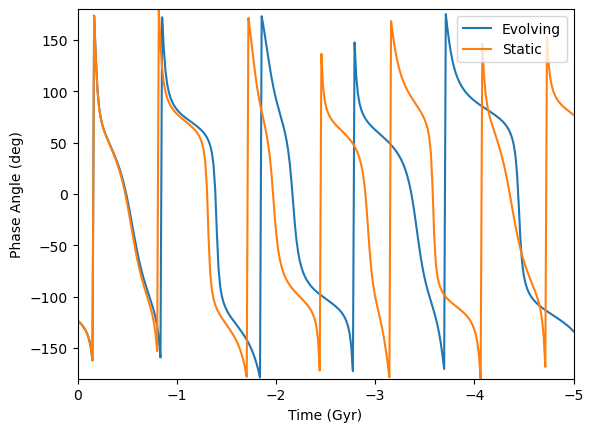

In [17]:
plt.plot(stream_model_half['times'], np.degrees(np.arctan2(stream_model_half['prog_xv'][:, 1], stream_model_half['prog_xv'][:, 0])), label = 'Evolving')
plt.plot(stream_model_stat['times'],np.degrees(np.arctan2(stream_model_stat['prog_xv'][:, 1], stream_model_stat['prog_xv'][:, 0])),label = 'Static' )
#plt.plot(stream_model_half['times'], np.degrees(np.arctan2(stream_model_half['prog_xv'][:, 1], stream_model_half['prog_xv'][:, 0])))
plt.ylabel('Phase Angle (deg)')
plt.xlabel('Time (Gyr)')
plt.ylim(-180,180)
plt.legend()
plt.xlim(0,-5)

In [77]:
#plotting density profile